# Camera calibration with a Charuco board in MuJoCo

This notebook demonstrates a complete camera-calibration workflow using a simulated camera, a robot, and a Charuco board.

The workflow is split into two main parts:

- **Intrinsic calibration** estimates the camera matrix from multiple board images.
- **Extrinsic calibration** estimates the pose of the camera with respect to the robot base.

Although this example runs in MuJoCo, the logical steps are the same as for a real setup: generate informative views of the board, detect the board reliably, save synchronized robot and image data, and solve the calibration problem from those measurements.

In [38]:
import numpy as np
import cv2
import glob
import os

import mediapy as media
import matplotlib.pyplot as plt

from IPython.display import clear_output
clear_output()

import mujoco
from robotblockset.mujoco.robots_pymujoco import mujoco_scene, panda
from robotblockset.transformations import rot_z, map_pose, t2x, x2t, frame2world, world2frame, uniqueCartesianPath, xerr
from robotblockset.tools import get_rbs_path
from robotblockset.graphics import display_images

from robotblockset.cameras.collect_calibration_data import create_data_dir, prepare_collect_calibration_data

from robotblockset.cameras.calibration_boards import CharucoBoard
from robotblockset.cameras.camera_calibration import detect_aruco_markers, detect_charuco_corners, detect_and_visualize_charuco_pose
from robotblockset.cameras.camera_calibration import get_pose_of_charuco_board
from robotblockset.cameras.camera_calibration import BoardDetectionResults, load_images, save_images
from robotblockset.cameras.camera_calibration import load_calibration_data
from robotblockset.cameras.camera_calibration import extrinsic_calibration_all_methods
from robotblockset.cameras.image_converter import ImageConverter

from robotblockset.cameras.mujoco_camera import MujocoCam

np.set_printoptions(precision=3, suppress=True, linewidth=100)

## Helper functions for the MuJoCo example

These helper functions save and load robot joint states, poses, images, and intrinsics in the same structure that is later used by the calibration routines.

In [2]:
import json
from robotblockset.cameras.camera_calibration import CameraIntrinsics, save_pose_to_json, load_pose_from_json

import numpy as np
from pathlib import Path


def save_q_to_json(q: np.ndarray, path: str | Path):
    """
    Save robot joint vector q (1D numpy array) to a JSON file.
    """
    q = np.asarray(q, dtype=float).reshape(-1)

    data = {
        "q": q.tolist(),
        "n_joints": int(q.size),
    }

    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(data, indent=2), encoding="utf-8")


def load_q_from_json(path: str | Path) -> np.ndarray:
    """
    Load robot joint vector q from a JSON file and return it as a numpy array.
    """
    path = Path(path)
    data = json.loads(path.read_text(encoding="utf-8"))

    if "q" not in data:
        raise ValueError("JSON does not contain key 'q'")

    q = np.asarray(data["q"], dtype=float)
    return q


def mujoco_save_calibration_sample(sample_index, robot, camera, data_dir):
    ROBOT_STOP_WAIT_TIME = 0.5
    robot.Wait(ROBOT_STOP_WAIT_TIME)

    image_rgb = camera.get_rgb_image_as_int()
    image_bgr = ImageConverter.from_numpy_int_format(image_rgb).image_in_opencv_format


    suffix = f"{sample_index:04d}"
    image_filename = f"image_{suffix}.png"
    image_filepath = os.path.join(data_dir, image_filename)
    tcp_pose_filename = f"tcp_pose_{suffix}.json"
    tcp_pose_filepath = os.path.join(data_dir, tcp_pose_filename)
    board_pose_filename = f"board_pose_{suffix}.json"
    board_pose_filepath = os.path.join(data_dir, board_pose_filename)
    camera_pose_filename = f"camera_pose_{suffix}.json"
    camera_pose_filepath = os.path.join(data_dir, camera_pose_filename)
    joint_filename = f"joint_{suffix}.json"
    joint_filepath = os.path.join(data_dir, joint_filename)

    cv2.imwrite(image_filepath, image_bgr)

    joints_pos = robot.q_ref
    tcp_pose = robot.GetPose()  # TODO: v katerem task_space
    pose = map_pose(x=tcp_pose, out="T")
    board_pose = robot.GetObjectPose("site", "plate_charuco_origin", out="T")
    camera_pose = robot.GetObjectPose('site','cam_frame', out="T")
    save_pose_to_json(tcp_pose_filepath, pose)        
    save_pose_to_json(board_pose_filepath, board_pose)        
    save_pose_to_json(camera_pose_filepath, camera_pose)        
    save_q_to_json(joints_pos, joint_filepath)
    

    return tcp_pose, board_pose, camera_pose, joints_pos, image_bgr

def mujoco_load_calibration_data(data_dir: str):
    intrinsics_path = os.path.join(data_dir, "intrinsics.json")
    with open(intrinsics_path, "r") as f:
        camera_intrinsics = CameraIntrinsics.model_validate_json(f.read())

    resolution = camera_intrinsics.image_resolution.as_tuple()
    intrinsics = camera_intrinsics.as_matrix()

    image_paths = sorted(glob.glob(os.path.join(data_dir, "image_*.png")))
    images = [cv2.imread(image_path) for image_path in image_paths]

    pose_paths = sorted(glob.glob(os.path.join(data_dir, "tcp_pose_*.json")))
    tcp_poses = []
    for filepath in pose_paths:
        pose = load_pose_from_json(filepath)
        tcp_poses.append(pose)

    board_pose_paths = sorted(glob.glob(os.path.join(data_dir, "board_pose_*.json")))
    board_poses = []
    for filepath in board_pose_paths:
        pose = load_pose_from_json(filepath)
        board_poses.append(pose)

    camera_pose_paths = sorted(glob.glob(os.path.join(data_dir, "camera_pose_*.json")))
    camera_poses = []
    for filepath in camera_pose_paths:
        pose = load_pose_from_json(filepath)
        camera_poses.append(pose)

    joint_paths = sorted(glob.glob(os.path.join(data_dir, "joint_*.json")))
    joints_pos = []
    for filepath in joint_paths:
        joints_pos.append(load_q_from_json(filepath))

    return images, tcp_poses, board_poses, camera_poses, joints_pos, intrinsics, resolution

# Initialization

In this section we create the simulation scene, robot, camera, Charuco board, and the output folder used to store captured calibration data.

## Scene


Load the MuJoCo scene that contains the robot, calibration board, and camera body.


In [3]:
MODEL_PATH = get_rbs_path() + "/mujoco/mjcf_models/"
HEIGHT = 480
WIDTH  = 640
scene_option = mujoco.MjvOption()
scene_option.sitegroup = [0, 0, 0, 0, 0, 0]
scene_option.geomgroup = [1, 1, 1, 0, 0, 0]
scene = mujoco_scene(f"{MODEL_PATH}/calibration_charuco_scene.xml", show_camera=None, verbose=2)
# print_body_tree_model(scene.model, "world")

[RBS_DEBUG] [1773380290.254851103] [MuJoCo Scene]: Model loaded successfully.
[RBS_DEBUG] [1773380290.255850792] [MuJoCo Scene]: Viewer started.


## Create robot object

Note: TCP is set to be in the center of the plate and alogned with plate orientation (using sites in model)


Create the robot interface used to move the Charuco plate through calibration poses.


In [4]:
r = panda(robot_name="panda", scene=scene)
r.ResetCurrentTarget()
# r.SetTCP(np.eye(4), frame="Flange")
r._default.Kinematics = "Calculated"
print("TCP: \n", r.TCP)

[RBS_INFO] [1773380290.513530731] [panda_PyMuJoCo]: Robot connected to MuJoCo
TCP: 
 [[-0.     0.707  0.707  0.   ]
 [ 0.     0.707 -0.707  0.   ]
 [-1.    -0.    -0.     0.228]
 [ 0.     0.     0.     1.   ]]


Move the robot to some initial configuration

In [ ]:
r.JMove(r.q_home)

[RBS_DEBUG] [1773380290.739427805] [MuJoCo Scene]: Viewer launched, running simulation...


0

## Create camera


Create the simulated RGB camera and assign nominal intrinsics used before calibration.


In [6]:
scene_option = mujoco.MjvOption()
scene_option.sitegroup = [0, 0, 0, 0, 0, 0]
scene_option.geomgroup = [1, 1, 1, 0, 1, 0]
# # K for  (640 x 480)
# intrinsics = np.array([[616.243,   0.   , 321.733],
#        [  0.   , 617.152, 242.248],
#        [  0.   ,   0.   ,   1.   ]])
# # K for (1280 x 960)
# intrinsics = np.array([[1241.521,    0.   ,  643.073],
#        [   0.   , 1239.811,  477.939],
#        [   0.   ,    0.   ,    1.   ]])
# K for (19200 x 108)
intrinsics = np.array([[1396.855,    0.   ,  969.601],
       [   0.   , 1393.465,  543.279],
       [   0.   ,    0.   ,    1.   ]])
# camera = MujocoCam(scene, mujoco_camera_id=0, scene_option=scene_option, intrinsics_matrix=intrinsics)
camera = MujocoCam(scene, mujoco_camera_id=0, resolution=(1920, 1080), scene_option=scene_option, intrinsics_matrix=intrinsics)

Define the position offset of the camera lenses regarding the camera frame.

This offset is useful later when comparing the simulated ground-truth camera pose with the pose recovered by extrinsic calibration.

In [7]:
camera_offset = map_pose(p=[0.002, -0.032, 0], out="T")

## Definition of charuco board used for calibration and data folder


Define the Charuco board that will be detected in the captured images.


CharucoBoard(7x5 squares, square=0.04 m, marker=0.031 m, dict=0, min_corners=10)


""

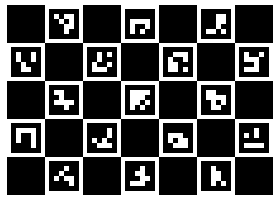

In [9]:
board = CharucoBoard(margin_size_m=0.005)
print(board)
media.show_image(board.image())

## Create data folder


Folder used for saved images, intrinsics, and extrinsic-calibration samples.


In [10]:
img_dir = "mujoco_charuco_calib"
path_img_dir = create_data_dir(img_dir)

[RBS_WARNING] [1773380293.208040714] [robotblockset.cameras.collect_calibration_data]: The data subfolder of mujoco_charuco_calib already exists and is not empty.


## Move camera and define object frame as camera frame


Place the robot-mounted plate in front of the camera and set the object frame to the camera frame.


In [11]:
r.SetMocapPose('cam_cam',[1.7, 0, 0.4])
r.Wait(0.5)
pcam = r.GetObjectPose('site','cam_frame')
r.SetObject(pcam)

In [12]:
r.TObject

array([[ 0. , -0. , -1. ,  1.7],
       [ 1. ,  0. , -0. ,  0. ],
       [ 0. , -1. ,  0. ,  0.4],
       [ 0. ,  0. ,  0. ,  1. ]])

In [13]:
pl = r.GetObjectPose('site','plate_charuco_origin')
print(r.WorldToObject(pl))

[-0.1    0.181  1.386  0.707  0.004  0.003 -0.707]


In [14]:
r.SetMocapPose("Target", pl)

In [15]:
r.TCP

array([[-0.   ,  0.707,  0.707,  0.   ],
       [ 0.   ,  0.707, -0.707,  0.   ],
       [-1.   , -0.   , -0.   ,  0.228],
       [ 0.   ,  0.   ,  0.   ,  1.   ]])

# Preliminary checks

Before collecting calibration data, it is useful to verify that the board is visible, that the detector works, and that the estimated board frame is drawn correctly in the image.

## Move to pose and check board detection

In [16]:
r.CMoveFor([0.1, 0, 0])

0

In [17]:
r.CMoveFor(rot_z(-np.pi / 8))

0

## Check board frame detection


Capture one image and convert it to OpenCV format for Charuco detection.


""

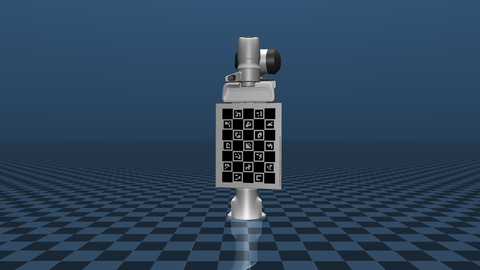

In [18]:
image_rgb = camera.get_rgb_image_as_int()
image_bgr = ImageConverter.from_numpy_int_format(image_rgb).image_in_opencv_format
gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
media.show_image(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB), width=camera.resolution[0] // 4, height=camera.resolution[1] // 4)

Detect the board and visualize all detected markers/corners.


""

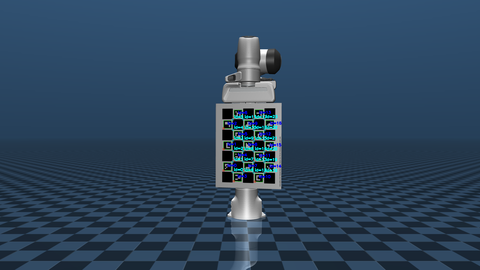

In [19]:
det = board.detect(gray)
img_det = board.drawDetection(image_bgr.copy(), det)
media.show_image(cv2.cvtColor(img_det, cv2.COLOR_BGR2RGB), width=camera.resolution[0] // 4, height=camera.resolution[1] // 4)

Estimate the board pose in the camera frame from the detected Charuco corners.


In [20]:
pose = board.detectPose(gray, camera.intrinsics_matrix(), None)
pose.as_pose()

array([-0.077,  0.177,  1.328,  0.706, -0.054,  0.063, -0.703])

""

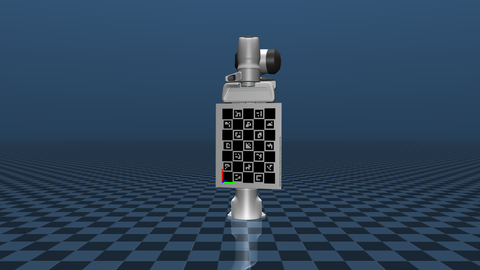

In [21]:
img = board.drawFrame(image_bgr, pose, camera.intrinsics_matrix(), None, length=0.05)
media.show_image(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), width=camera.resolution[0] // 4, height=camera.resolution[1] // 4)

## Testing module functions

In [22]:
image_bgr = image_rgb.copy()

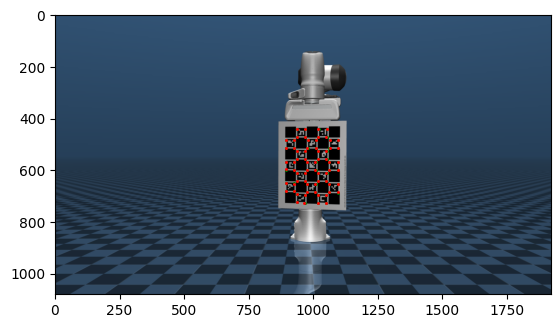

In [23]:
res1 = detect_aruco_markers(image_bgr, board.dictionary)
res2 = detect_charuco_corners(image_bgr, res1, board.board)
res0 = BoardDetectionResults(*board.detector.detectBoard(image_bgr))
fig, axes = plt.subplots(1, 1)
axes.imshow(image_bgr)
axes.scatter(
    np.array(res1.corners).squeeze().reshape(-1, 2)[:, 0],
    np.array(res1.corners).squeeze().reshape(-1, 2)[:, 1],
    s=5,
    c="green",
    marker=".",
)
axes.scatter(
    np.array(res0.aruco_corners).squeeze().reshape(-1, 2)[:, 0],
    np.array(res0.aruco_corners).squeeze().reshape(-1, 2)[:, 1],
    s=5,
    c="red",
    marker=".",
)


In [24]:
detected_pose = get_pose_of_charuco_board(res2, board.board, camera_matrix=intrinsics)
print("Detected pose:\n", detected_pose)

Detected pose:
 [[ 0.003  0.986  0.164 -0.077]
 [-1.     0.005 -0.012  0.176]
 [-0.013 -0.164  0.986  1.328]
 [ 0.     0.     0.     1.   ]]


""

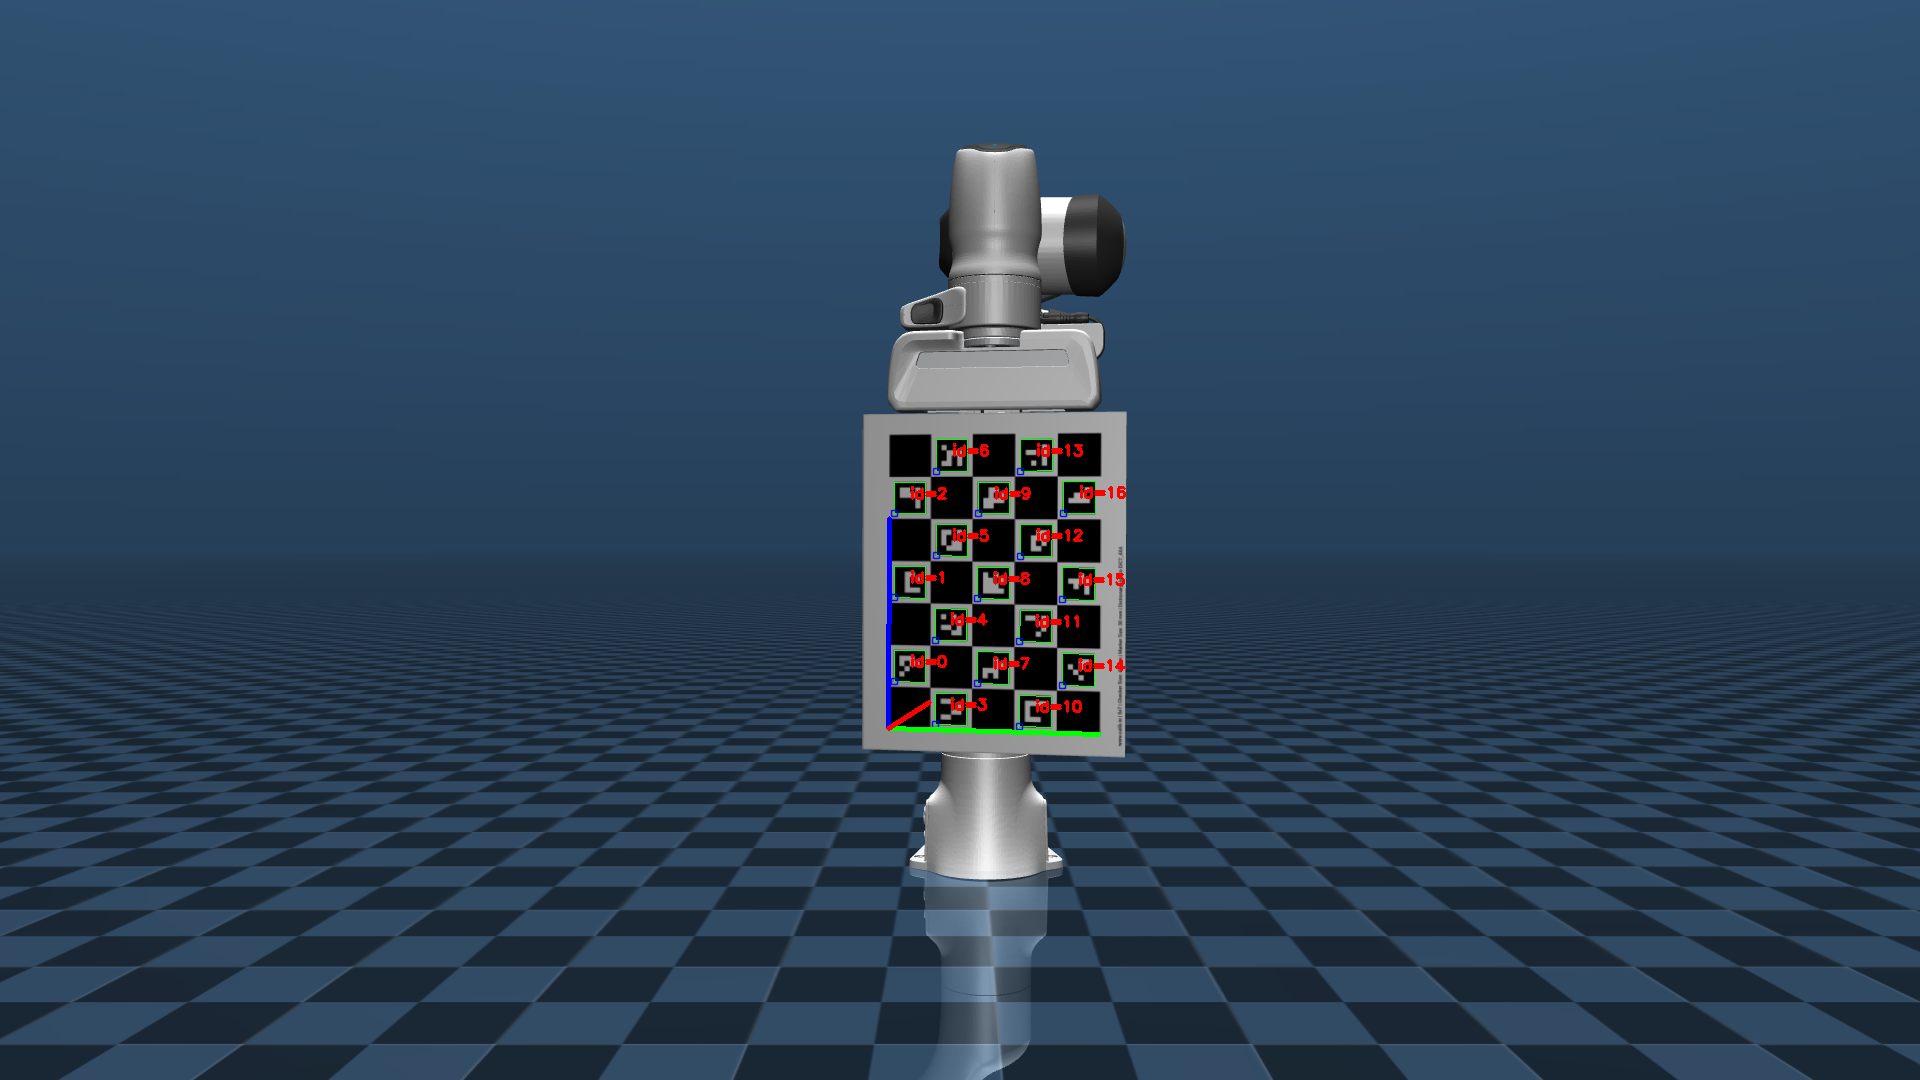

In [25]:
detected_pose = detect_and_visualize_charuco_pose(image_bgr, camera.intrinsics_matrix(), board.dictionary, board.board, draw_aruco_detection=True, draw_charuco_detection=False)
media.show_image(image_bgr)


# Intrinsic calibration

Intrinsic calibration estimates focal lengths, principal point, and related camera parameters from multiple images of the Charuco board observed under varied poses.

## Motion generation

Selected pose where the plate is in the middle of camera view and oriented approximately to the camera


Move the robot to a nominal pose from which random calibration views will be generated.


In [26]:
x0 = np.array([0.4, -0.   ,  0.5 ,  0, -0.71 , 0,  -0.704])
r.JMove(r.q_home)
r.CMove(x0)
q0 = r.q_ref
r.JMove(q0)

0

Execute test motion


Capture a set of varied board views for intrinsic calibration.


In [27]:
images=[]
it=0
for i in range(12):
    # xx = map_pose(p=x0[:3] + np.random.randn(3) * [0.1, 0.2, 0.05], RPY=map_pose(Q=x0[3:], out="RPY") + np.random.randn(3) * 0.4)
    r.JMove(q0)
    r.CMoveFor(np.random.randn(3) * [0.05, 0.2, 0.1])
    r.CMoveFor(map_pose(RPY=[np.random.uniform(-1, 1) * 0.9, np.random.uniform(-1, 1) * 0.3, np.random.uniform(-1, 1) * 0.9], out="Q"))
    r.Wait(0.2)
    image_rgb = camera.get_rgb_image_as_int()
    image_bgr = ImageConverter.from_numpy_int_format(image_rgb).image_in_opencv_format
    images.append(image_bgr)

Save imegaes

In [28]:
save_images(img_dir, images)

## Load captured images

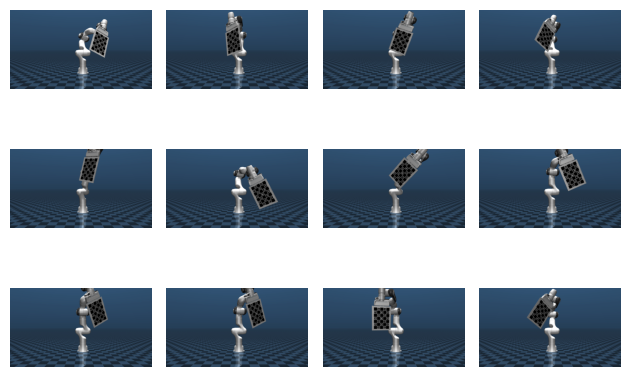

In [29]:
images = load_images(img_dir)
display_images(images, bgr2rgb=True)

media.show_images([frames[i] for i in range(len(frames))], height=240, columns=4)


## Calculate intrinsics


Solve for camera intrinsics from the collected calibration images.


In [31]:
calib_res = board.intrinsic_calibration(images, silent=True)
print("Matrix:\n", calib_res.to_camera_intrinsics().as_matrix())

Matrix:
 [[1400.528    0.     958.268]
 [   0.    1395.915  528.861]
 [   0.       0.       1.   ]]


Save to JSON file

In [32]:
calib_res.write_intrinsics_json("mujoco",camera.name, out_dir=img_dir)

WindowsPath('mujoco_charuco_calib/mujoco_cam_RGB_intrinsic_calibration.json')

Set camera intrinsics


In [33]:
camera._intrinsics_matrix = calib_res.to_camera_intrinsics().as_matrix()

# Extrinsic calibration

Extrinsic calibration estimates the rigid transform between the robot base and the camera. For that, each sample must contain an image together with the corresponding robot TCP pose and the simulated ground-truth poses available in MuJoCo.

## Prepare data folder


Create the directory structure expected by the extrinsic-calibration utilities.


In [34]:
data_dir = prepare_collect_calibration_data(camera, img_dir)

[RBS_WARNING] [1773380347.497888565] [robotblockset.cameras.collect_calibration_data]: The data subfolder of mujoco_charuco_calib already exists and is not empty.
[RBS_INFO] [1773380347.499588251] [robotblockset.cameras.collect_calibration_data]: Saving calibration data to mujoco_charuco_calib\data


## Move to init pose


Return to the nominal pose before sampling random extrinsic-calibration views.


In [35]:
x0 = np.array([0.4, -0.   ,  0.5 ,  0, -0.71 , 0,  -0.704])
r.JMove(r.q_home)
r.CMove(x0)
q0 = r.q_ref
r.JMove(q0)

0

## Capture and save random poses and images


Save image-plus-pose samples for extrinsic calibration.


In [36]:
for sample_index in range(20):
    r.JMove(q0)
    r.CMoveFor(np.random.randn(3) * [0.05, 0.2, 0.1])
    r.CMoveFor(map_pose(RPY=[np.random.uniform(-1, 1) * 0.9, np.random.uniform(-1, 1) * 0.3, np.random.uniform(-1, 1) * 0.9], out="Q"))
    tcp_pose, board_pose, camera_pose, joint_pos, image_bgr = mujoco_save_calibration_sample(sample_index, r, camera, data_dir)  # type: ignore
    print(f"Saved {sample_index+1} sample(s).")

Saved 1 sample(s).
Saved 2 sample(s).
Saved 3 sample(s).
Saved 4 sample(s).
Saved 5 sample(s).
Saved 6 sample(s).
Saved 7 sample(s).
Saved 8 sample(s).
Saved 9 sample(s).
Saved 10 sample(s).
Saved 11 sample(s).
Saved 12 sample(s).
Saved 13 sample(s).
Saved 14 sample(s).
Saved 15 sample(s).
Saved 16 sample(s).
Saved 17 sample(s).
Saved 18 sample(s).
Saved 19 sample(s).
Saved 20 sample(s).


## Load captured images


Load the saved images together with the corresponding robot, board, and camera poses.


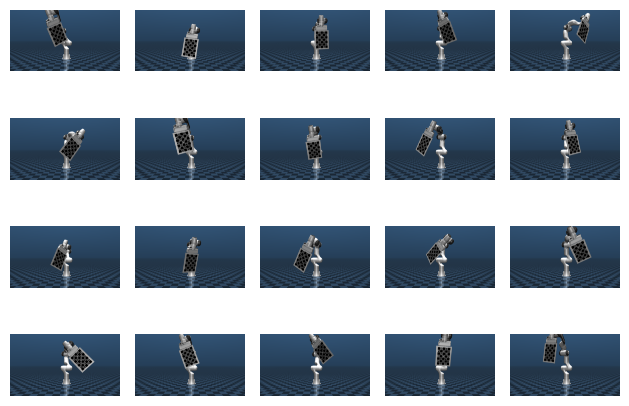

In [39]:
images, tcp_poses, board_poses, camera_poses, joint_poses, intrinsics, resolution = mujoco_load_calibration_data(data_dir)
display_images(images, bgr2rgb=True)

## Check board detection

Select one captured pose

In [40]:
ii = 8
actual_board_T = board_poses[ii]
img = images[ii]
cam_T = camera_poses[ii]
qq = joint_poses[ii]


Move to selected configuration

In [41]:
_ = r.JMove(qq)
r.SetMocapPose("Target", actual_board_T)

Check board detection


Compare the detected board pose with the simulated ground-truth pose for one sample.


Detected board pose in camera frame:  [-0.4    0.015  1.388  0.82  -0.214  0.211 -0.487]
Actual   board pose in camera frame:  [-0.435  0.004  1.378  0.821 -0.213  0.21  -0.487]


""

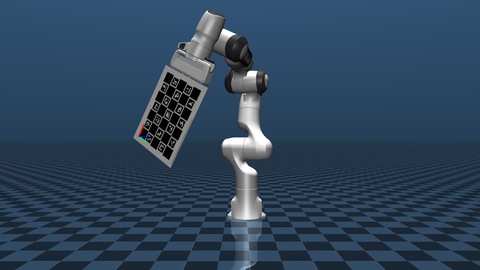

In [42]:
detected_pose = board.detectPose(img, camera.intrinsics_matrix(), None).as_pose()
print("Detected board pose in camera frame: ", detected_pose)
actual_board_pose = uniqueCartesianPath(t2x(actual_board_T))
print("Actual   board pose in camera frame: ", world2frame(actual_board_pose,cam_T))
img_vis = board.drawFrame(img, detected_pose, camera.intrinsics_matrix(), None, length=0.05)
media.show_image(cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB), width=camera.resolution[0] // 4, height=camera.resolution[1] // 4)

## Check board detection for all captured poses

Note: Position error is due to offset between camera center and RGBCamera location 


Run the detector on all saved images and inspect pose errors across the dataset.


 19:  Board pos in camera frame: [-0.389 -0.071  1.354  0.732 -0.156  0.158 -0.644]  detected: [-0.354 -0.061  1.362  0.731 -0.158  0.158 -0.644]  error: [-0.035 -0.01  -0.008  0.004 -0.002  0.001]
 18:  Board pos in camera frame: [-0.085 -0.007  1.302  0.724  0.095  0.052 -0.681]  detected: [-0.05   0.003  1.31   0.725  0.091  0.048 -0.681]  error: [-0.035 -0.01  -0.008  0.01   0.001  0.   ]
 17:  Board pos in camera frame: [ 0.107 -0.036  1.336  0.42  -0.249  0.218 -0.845]  detected: [ 0.14  -0.026  1.34   0.419 -0.255  0.213 -0.845]  error: [-0.033 -0.01  -0.004  0.014 -0.007 -0.004]
 16:  Board pos in camera frame: [-0.093  0.033  1.289  0.568 -0.082  0.028 -0.819]  detected: [-0.059  0.043  1.296  0.567 -0.089  0.028 -0.818]  error: [-0.035 -0.009 -0.007  0.008 -0.012 -0.   ]
 15:  Board pos in camera frame: [ 0.244  0.089  1.241  0.394 -0.102  0.033 -0.913]  detected: [ 0.277  0.098  1.251  0.393 -0.118  0.044 -0.911]  error: [-0.033 -0.009 -0.01  -0.008 -0.037  0.001]
 14:  Boar

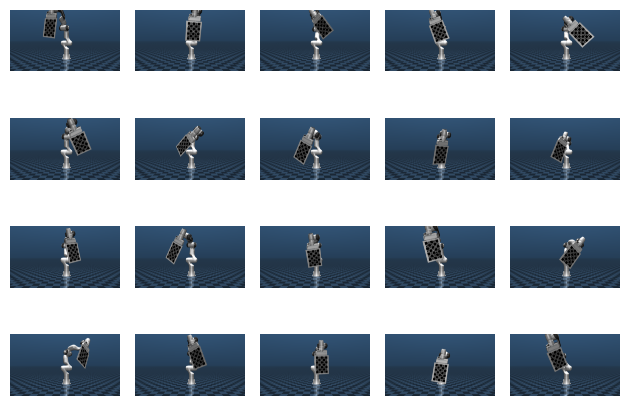

In [43]:
board_images = []
detected_poses = []
for ii in reversed(range(len(images))):
    img = images[ii].copy()
    detected_pose = board.detectPose(img, camera.intrinsics_matrix(), None).as_pose()
    if detected_pose is None:
        images.pop(ii)
        tcp_poses.pop(ii)
        board_poses.pop(ii)
        camera_poses.pop(ii)
    else:
        board_images.append(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        actual_board_pose = uniqueCartesianPath(t2x(r.WorldToObject(board_poses[ii])))
        print(f"{ii:3d}:  Board pos in camera frame: {actual_board_pose}  detected: {detected_pose}  error: {xerr(actual_board_pose, detected_pose)}")
        # actual_board_pose = world2frame(board_poses[ii], camera_poses[ii])
        # print(f"{ii}:  Board pos in camera frame: {t2x(board_pose_in_camera_frame)}  detected: {t2x(detected_pose)}")
        detected_poses.append(detected_pose)
display_images(board_images)

## Eye_to_hand Calibration


In [44]:
results_dir = os.path.join(img_dir, f"results")
os.makedirs(results_dir, exist_ok=True)
print(results_dir)

mujoco_charuco_calib\results


In [45]:

images, tcp_poses, intrinsics, resolution = load_calibration_data(img_dir)


Solve the eye-to-hand calibration with several methods and keep the lowest-error result.


In [46]:
poses_dict, errors_dict = extrinsic_calibration_all_methods(results_dir, images, tcp_poses, intrinsics, mode="eye_to_hand")
min_error_key = min(errors_dict, key=lambda x: errors_dict.get(x) or float("inf"))
camera_pose_best = poses_dict[min_error_key]


[RBS_INFO] [1773380517.605333090] [robotblockset.cameras.camera_calibration]: Board poses were detected in 20 of the calibration samples.
[RBS_INFO] [1773380517.608672619] [robotblockset.cameras.camera_calibration]: Residual error Tsai: 0.0158
[RBS_INFO] [1773380517.622253418] [robotblockset.cameras.camera_calibration]: Residual error Park: 0.0157
[RBS_INFO] [1773380517.633229256] [robotblockset.cameras.camera_calibration]: Residual error Haraud: 0.0156
[RBS_INFO] [1773380517.647307158] [robotblockset.cameras.camera_calibration]: Residual error Andreff: 0.0175
[RBS_INFO] [1773380517.654978275] [robotblockset.cameras.camera_calibration]: Residual error Daniilidis: 0.0151


Actual and detected camera pose in robot frame

In [47]:
print("Actual camera pose:\n", camera_offset @ x2t(uniqueCartesianPath(r.GetObjectPose("site",'cam_frame'))))
print("Detected camera pose:\n", camera_pose_best)

Actual camera pose:
 [[ 0.    -0.    -1.     1.702]
 [ 1.     0.    -0.    -0.032]
 [ 0.    -1.     0.     0.4  ]
 [ 0.     0.     0.     1.   ]]
Detected camera pose:
 [[-0.005 -0.003 -1.     1.71 ]
 [ 1.    -0.002 -0.005 -0.026]
 [-0.002 -1.     0.003  0.408]
 [ 0.     0.     0.     1.   ]]


### Print robot frame in one of images

Camera position in robot frame 

In [48]:
robot_base_in_camera_frame = np.linalg.inv(camera_pose_best)

Select image and draw robot frame in it

""

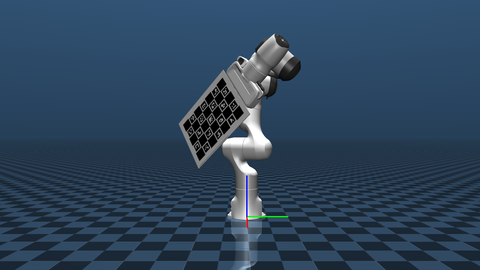

In [49]:
ii = 13
img = images[ii]
img_vis = board.drawFrame(img, robot_base_in_camera_frame, camera.intrinsics_matrix(), None, length=0.2)
media.show_image(cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB), width=camera.resolution[0] // 4, height=camera.resolution[1] // 4)

# Useful relations

After calibration, camera-frame detections can be transformed into the robot frame. The following examples show how to use the estimated camera pose to localize the board and individual ArUco markers.

## Camera position in robot frame 


Use the best estimated camera pose from the extrinsic calibration step.


In [50]:
camera_pose = camera_pose_best
print("Final camera pose:\n", camera_pose)

Final camera pose:
 [[-0.005 -0.003 -1.     1.71 ]
 [ 1.    -0.002 -0.005 -0.026]
 [-0.002 -1.     0.003  0.408]
 [ 0.     0.     0.     1.   ]]


Move robot to some configuration

In [51]:
r.JMove(q0)


0

In [52]:
r.CMoveFor([0.1, 0, 0])

0

In [53]:
r.CMoveFor(np.random.randn(3) * [0.05, 0.2, 0.1])
r.CMoveFor(map_pose(RPY=[np.random.randn(1) * 0.7, np.random.randn(1) * 0.3, np.random.randn(1) * 0.7], out="Q"))
r.Wait(0.2)

Detect board


Detect the board in the current image and recover its pose in the camera frame.


""

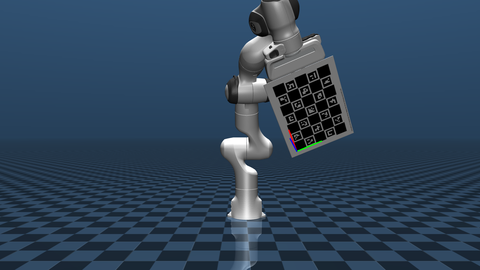

In [54]:
image_rgb = camera.get_rgb_image_as_int()
image_bgr = ImageConverter.from_numpy_int_format(image_rgb).image_in_opencv_format
board_T = board.detectPose(image_bgr, intrinsics).as_homogeneous_matrix()
img = board.drawFrame(image_bgr,board_T, intrinsics)
media.show_image(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), width=camera.resolution[0] // 4, height=camera.resolution[1] // 4)

Position of board in robot frame

In [55]:
board_T_robot = frame2world(board_T, camera_pose)
print("Detected board pose in robot frame: ", t2x(board_T_robot))

actual_board_pose = uniqueCartesianPath(r.GetObjectPose("site",'plate_charuco_origin'))
print("Actual   board pose in robot frame: ", actual_board_pose)

Detected board pose in robot frame:  [ 0.391  0.182  0.34   0.846  0.151 -0.495 -0.128]
Actual   board pose in robot frame:  [ 0.388  0.182  0.339  0.847  0.15  -0.493 -0.133]


In [56]:
r.SetMocapPose("Target", board_T_robot)

## Position of aruco and charuco markers in robot frame

Capture image

In [57]:
image_rgb = camera.get_rgb_image_as_int()
image_bgr = ImageConverter.from_numpy_int_format(image_rgb).image_in_opencv_format


Detect aruco and charuco markers

""

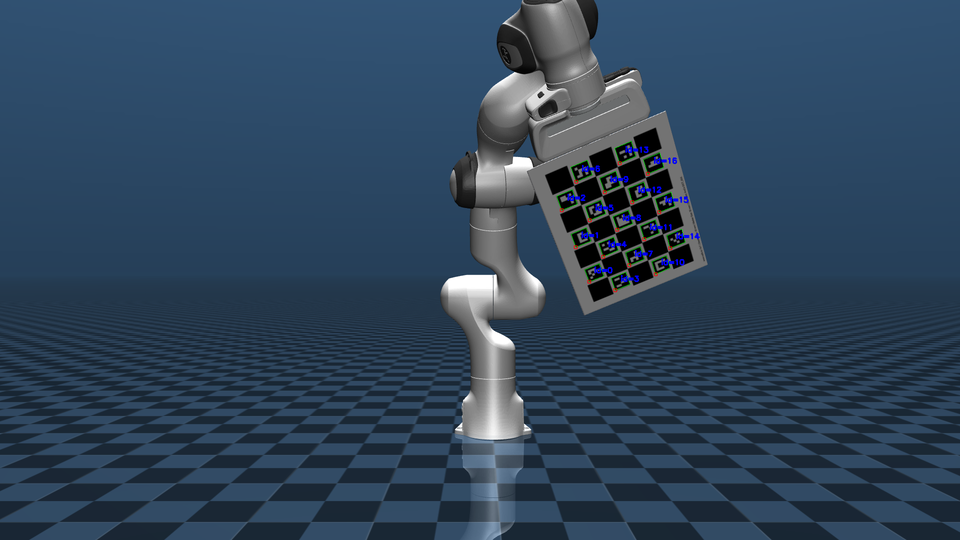

In [58]:
det_result = board.detect(image_bgr)

img = board.drawDetection(image_bgr,det_result, draw_charuco=False)
media.show_image(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), width=camera.resolution[0] // 2, height=camera.resolution[1] // 2)


""

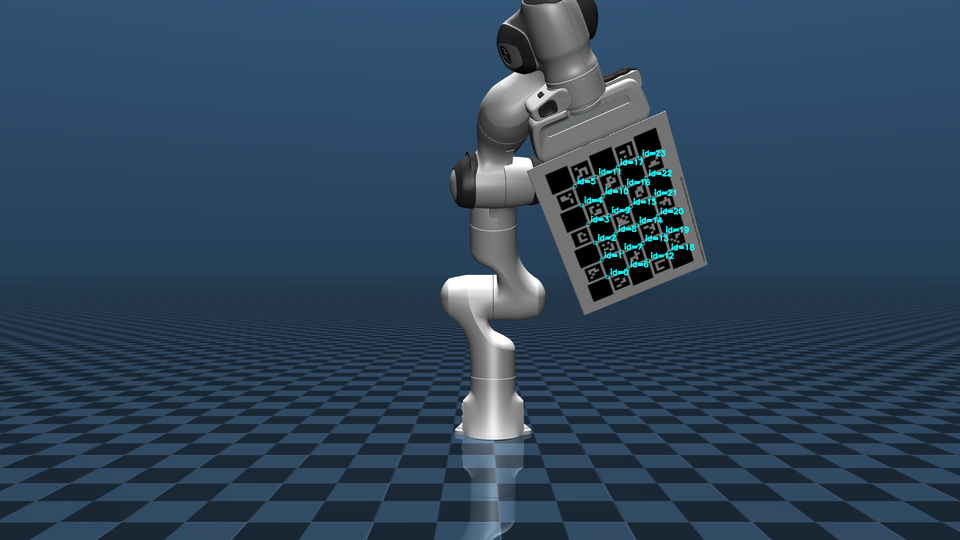

In [59]:
img = board.drawDetection(image_bgr,det_result, draw_aruco=False)
media.show_image(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), width=camera.resolution[0] // 2, height=camera.resolution[1] // 2)

List all marker positions in robot frame


Convert all detected marker poses from the camera frame into the robot frame.


In [60]:
marker_poses_in_camera_frame = board.get_poses_of_aruco_markers(det_result, intrinsics)
marker_poses_in_robot_frame = frame2world(marker_poses_in_camera_frame, camera_pose)
for i, pose in enumerate(marker_poses_in_robot_frame):
    print(f"Aruco marker ID {int(det_result.aruco_ids[i][0]):2d}:   Pose in robot frame: {t2x(pose)}")

# t2x(marker_poses_in_camera_frame)

Aruco marker ID 13:   Pose in robot frame: [ 0.463  0.228  0.612  0.155 -0.851  0.13  -0.484]
Aruco marker ID  6:   Pose in robot frame: [ 0.467  0.15   0.578  0.153 -0.862  0.134 -0.465]
Aruco marker ID 16:   Pose in robot frame: [ 0.443  0.283  0.595  0.142 -0.865  0.142 -0.46 ]
Aruco marker ID  9:   Pose in robot frame: [ 0.427  0.207  0.563  0.156 -0.851  0.128 -0.484]
Aruco marker ID  2:   Pose in robot frame: [ 0.402  0.131  0.533  0.147 -0.839  0.122 -0.509]
Aruco marker ID  5:   Pose in robot frame: [ 0.419  0.181  0.512  0.018  0.502 -0.229  0.834]
Aruco marker ID 12:   Pose in robot frame: [ 0.401  0.264  0.547  0.064  0.52  -0.248  0.815]
Aruco marker ID 15:   Pose in robot frame: [ 0.403  0.314  0.528  0.144 -0.857  0.127 -0.479]
Aruco marker ID  8:   Pose in robot frame: [ 0.387  0.238  0.496  0.139 -0.857  0.141 -0.475]
Aruco marker ID  1:   Pose in robot frame: [ 0.369  0.162  0.464  0.164 -0.847  0.108 -0.493]
Aruco marker ID  4:   Pose in robot frame: [ 0.364  0.215  0

Select one marker and show frame on image


Pick one marker, visualize its camera-frame pose in the image, and compare it in the robot frame.


""

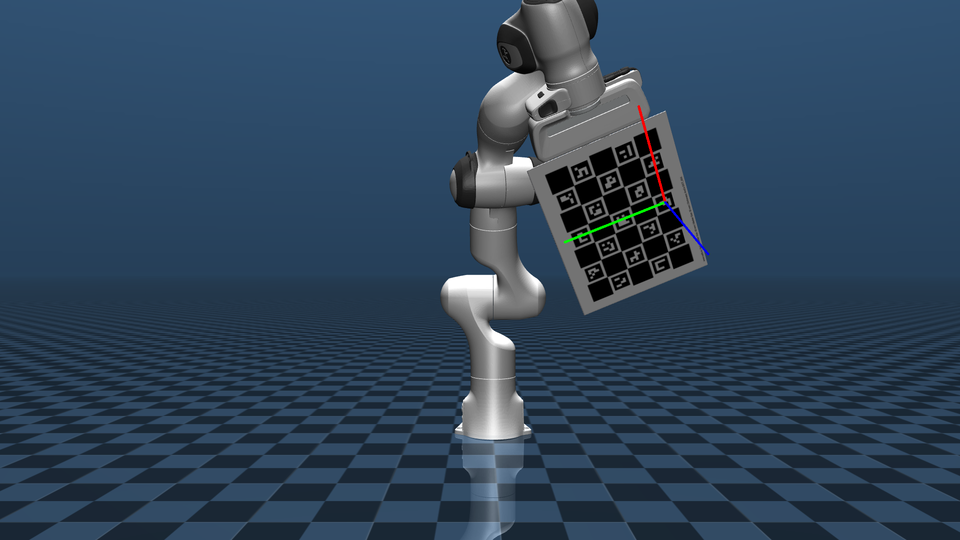

In [61]:
marker_cam = marker_poses_in_camera_frame[7]
marker_rob = marker_poses_in_robot_frame[7]
img = board.drawFrame(image_bgr, marker_cam, intrinsics, length=0.2)
media.show_image(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), width=camera.resolution[0] // 2, height=camera.resolution[1] // 2)

Check detected marker on robot

In [ ]:
r.SetMocapPose("Target", marker_rob)

: 